<a href="https://colab.research.google.com/github/pratripat/English-to-Hindi-Translator/blob/main/EngToHindi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Pipeline

## Step 1: Load raw corpus

The download stopped working for some reason, had to use the github repo to download files. Currently storing them in the drive and using them instead which reduces install time.

In [1]:
#from datasets import load_dataset

In [2]:
# IITB English-Hindi parallel corpus, standard benchmark for this task.
# ~1.66M train pairs, ~2500 val, ~2500 test.
# raw = load_dataset("cfilt/iitb-english-hindi")

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:

# Install git-lfs
!apt-get -qq install git-lfs
!git lfs install

# Clone only if it doesn't already exist
!if [ ! -d "/content/drive/MyDrive/en_hi_transformer/datasets/iitb" ]; then \
    git clone https://huggingface.co/datasets/cfilt/iitb-english-hindi \
    /content/drive/MyDrive/en_hi_transformer/datasets/iitb; \
else \
    echo "Dataset already exists."; \
fi

Selecting previously unselected package git-lfs.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...
Git LFS initialized.
Dataset already exists.


In [5]:
from datasets import load_dataset

DATA_DIR = "/content/drive/MyDrive/en_hi_transformer/datasets/iitb/data"

raw = load_dataset(
    "parquet",
    data_files={
        "train": f"{DATA_DIR}/train-00000-of-00001.parquet",
        "validation": f"{DATA_DIR}/validation-00000-of-00001.parquet",
        "test": f"{DATA_DIR}/test-00000-of-00001.parquet",
    }
)

print(raw)
print(raw["train"][0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})
{'translation': {'en': 'Give your application an accessibility workout', 'hi': 'अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें'}}


In [6]:
print(raw["train"].features)

{'translation': {'en': Value('string'), 'hi': Value('string')}}


## Step 2: Clean and filter the corpus to something that can be used

In [7]:
import re
import unicodedata
from tqdm import tqdm

In [8]:
def strip_control_characters(text: str) -> str:
  # Remove control/format/private-use/surrogate Unicode characters.
  # Without this, SentencePiece's character_coverage setting can't tell "rare but real character" apart from "corrupted byte" --
  # the model will then use this corrupted byte in the output as well
  return "".join(ch for ch in text if unicodedata.category(ch) not in ("Cc", "Cf", "Co", "Cs"))

In [9]:
# Cleans a given text
def basic_clean(text: str) -> str:
  text = strip_control_characters(text)
  text = text.strip() # Remove trailing white spaces
  text = re.sub(r"\s+", " ", text) # This collapses multiple spaces, tabs into one space. This helps the model retain context or make multiple tokens for the spaces and tabs.
  return text

In [10]:
# Filters out the pairs that are actually relevant
def filter_pair(en: str, hi: str, min_len=1, max_len=40, max_ratio=2.5):
  en_toks = en.split()
  hi_toks = hi.split()

  # There should be atleast one token that will be converted into hindi tokens.
  # Max length is kept because the conversion is a costly task O(n^2)
  if not en_toks or not hi_toks:
      return False
  if len(en_toks) < min_len or len(hi_toks) < min_len:
      return False
  if len(en_toks) > max_len or len(hi_toks) > max_len:
      return False

  # When some english sentence is converted into another language, it is usually relatively similar size
  # in terms of tokens, if we have 50 words being converted to 3 words, then the conversion is probably wrong
  # the data fetching might have problems or the data set might have some irrelevant conversions
  # (sentence alignment error)
  ratio = len(en_toks) / len(hi_toks)
  if ratio > max_ratio or ratio < (1 / max_ratio):
      return False

  return True

In [11]:
def clean_and_filter_split(split, max_len=40, max_ratio=2.5):
  en_lines = []
  hi_lines = []
  seen = set()

  for ex in tqdm(split, desc='cleaning'):
    en = basic_clean(ex['translation']['en'])
    hi = basic_clean(ex['translation']['hi'])

    if not filter_pair(en, hi, max_len=max_len, max_ratio=max_ratio):
      continue

    if (en, hi) in seen:
      continue

    seen.add((en, hi))
    en_lines.append(en)
    hi_lines.append(hi)

  return en_lines, hi_lines

In [12]:
DEV_SUBSET_SIZE = 1700000 # Starting small just for pipelining sake

Shuffling before subsetting.

This is important because the dataset has several sub-corpora (software UI strings, subtitles, news, etc.) and it is not pre shuffled. So during subsetting, the train might end up getting data from a specific sub-corpora itself and not the whole thing, which will lead to the model not fitting well.

In [13]:
raw['train'] = raw['train'].shuffle(seed=42)

In [14]:
PROJECT_DIR = "/content/drive/MyDrive/en_hi_transformer"

In [15]:
# train_subset = raw["train"].select(range(min(DEV_SUBSET_SIZE, len(raw["train"]))))

# train_en, train_hi = clean_and_filter_split(train_subset)
# val_en, val_hi = clean_and_filter_split(raw['validation'])
# test_en, test_hi = clean_and_filter_split(raw['test'])

import os
from datasets import Dataset, DatasetDict, load_from_disk

CACHE_DIR = f"{PROJECT_DIR}/datasets/cleaned_{DEV_SUBSET_SIZE}"

if os.path.exists(CACHE_DIR):
    print("Loading cleaned dataset...")

    cleaned = load_from_disk(CACHE_DIR)

    train_en = cleaned["train"]["en"]
    train_hi = cleaned["train"]["hi"]

    val_en = cleaned["validation"]["en"]
    val_hi = cleaned["validation"]["hi"]

    test_en = cleaned["test"]["en"]
    test_hi = cleaned["test"]["hi"]

else:
    print("Cleaning dataset...")

    train_subset = raw["train"].select(range(min(DEV_SUBSET_SIZE, len(raw["train"]))))

    train_en, train_hi = clean_and_filter_split(train_subset)
    val_en, val_hi = clean_and_filter_split(raw["validation"])
    test_en, test_hi = clean_and_filter_split(raw["test"])

    cleaned = DatasetDict({
        "train": Dataset.from_dict({
            "en": train_en,
            "hi": train_hi
        }),
        "validation": Dataset.from_dict({
            "en": val_en,
            "hi": val_hi
        }),
        "test": Dataset.from_dict({
            "en": test_en,
            "hi": test_hi
        }),
    })

    cleaned.save_to_disk(CACHE_DIR)

Loading cleaned dataset...


In [16]:
print(f"train pairs kept: {len(train_en)}")
print(f"val pairs kept:   {len(val_en)}")
print(f"test pairs kept:  {len(test_en)}")

train pairs kept: 1266271
val pairs kept:   508
test pairs kept:  2296


## Step 3: Writing the data into plain files for SentencePiece training

In [17]:
import os

In [18]:
os.makedirs("data", exist_ok=True)

def write_lines(lines, path):
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

write_lines(train_en, "data/train.en")
write_lines(train_hi, "data/train.hi")
write_lines(val_en, "data/val.en")
write_lines(val_hi, "data/val.hi")
write_lines(test_en, "data/test.en")
write_lines(test_hi, "data/test.hi")

## Step 4: Training the tokenizers

In [19]:
import sentencepiece as spm

We will be using two different vocabs for english and hindi. This is because we will never encounter a scenario where we need both the english and hindi contents together. So there is no point forcing both the tokens to be in one table. The encoder uses the english vocab and the decoder uses the hindi vocab (for generation) along with the english vocab.

In [20]:
VOCAB_SIZE_EN = 8000
VOCAB_SIZE_HI = 8000

In [21]:
def train_sentencepiece(input_file, model_prefix, vocab_size):
    spm.SentencePieceTrainer.train(
        input=input_file,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        model_type="bpe", # byte pair encoding
        character_coverage=0.9995,  # important for Hindi: keeps rare Devanagari chars
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3,
        pad_piece="<pad>",
        unk_piece="<unk>",
        bos_piece="<bos>",
        eos_piece="<eos>",
    )

In [22]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os
TOKENIZER_DIR = f"{PROJECT_DIR}/tokenizer"
os.makedirs(TOKENIZER_DIR, exist_ok=True)

In [24]:
EN_MODEL_PREFIX = f"{TOKENIZER_DIR}/spm_en"
HI_MODEL_PREFIX = f"{TOKENIZER_DIR}/spm_hi"

In [25]:
# Train only once
if not os.path.exists(f"{EN_MODEL_PREFIX}.model"):
    train_sentencepiece(
        "data/train.en",
        EN_MODEL_PREFIX,
        VOCAB_SIZE_EN
    )

if not os.path.exists(f"{HI_MODEL_PREFIX}.model"):
    train_sentencepiece(
        "data/train.hi",
        HI_MODEL_PREFIX,
        VOCAB_SIZE_HI
    )

In [26]:
# Load the model saved from drive
sp_en = spm.SentencePieceProcessor(
    model_file=f"{EN_MODEL_PREFIX}.model"
)

sp_hi = spm.SentencePieceProcessor(
    model_file=f"{HI_MODEL_PREFIX}.model"
)

In [27]:
# Sanity check -- always eyeball this before trusting the tokenizer
sample_en = train_en[0]
sample_hi = train_hi[0]
print("EN:", sample_en)
print("EN tokens:", sp_en.encode(sample_en, out_type=str))
print("HI:", sample_hi)
print("HI tokens:", sp_hi.encode(sample_hi, out_type=str))

EN: on the intuition.
EN tokens: ['▁on', '▁the', '▁int', 'u', 'ition', '.']
HI: अंतर्ज्ञान पर।
HI tokens: ['▁अंतर्', 'ज्ञान', '▁पर', '।']


The tokens are being created properly (as it should have)

## Step 5: Dataset

In [28]:
import torch
from torch.utils.data import Dataset

In [29]:
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
MAX_SEQ_LEN = 64

In [30]:
# Pre-tokenize everything, avoids retokenizing every epoch and lazy tokenizes in __getitem__
class TranslationDataset(Dataset):
  def __init__(self, en_lines, hi_lines, sp_en, sp_hi, max_len=MAX_SEQ_LEN):
    assert len(en_lines) == len(hi_lines)
    self.max_len = max_len

    self.en_ids = []
    self.hi_ids = []

    for en, hi in zip(en_lines, hi_lines):
      en_ids = sp_en.encode(en, out_type=int)[: max_len - 1] + [EOS_ID]
      # Decoder input needs BOS_ID token at the start, target needs EOS_ID token at the end which is added later
      hi_ids = sp_hi.encode(hi, out_type=int)[: max_len - 2]

      self.en_ids.append(en_ids)
      self.hi_ids.append(hi_ids)

  def __len__(self):
    return len(self.en_ids)

  def __getitem__(self, idx):
    return self.en_ids[idx], self.hi_ids[idx]

In [31]:
train_dataset = TranslationDataset(train_en, train_hi, sp_en, sp_hi)
val_dataset = TranslationDataset(val_en, val_hi, sp_en, sp_hi)

In [32]:
print(f'train size: {len(train_dataset)}')
print(f'val size: {len(val_dataset)}')

train size: 1266271
val size: 508


## Step 6: Adding paddings and masks

In [33]:
from torch.nn.utils.rnn import pad_sequence

In [34]:
def collate_fn(batch):
  # batch: list of (en_ids, hi_ids) tuples of variable lengths

  en_batch, hi_batch = zip(*batch)
  en_tensors = [torch.tensor(x, dtype=torch.long) for x in en_batch]
  dec_in_tensors = [
    torch.cat([
      torch.tensor([BOS_ID], dtype=torch.long),
      torch.tensor(x, dtype=torch.long)
    ])
    for x in hi_batch
  ]

  dec_tgt_tensors = [
    torch.cat([
      torch.tensor(x, dtype=torch.long),
      torch.tensor([EOS_ID], dtype=torch.long)
    ])
    for x in hi_batch
  ]

  en_padded = pad_sequence(en_tensors, batch_first=True, padding_value=PAD_ID) # (B, src_len)
  dec_in_padded = pad_sequence(dec_in_tensors, batch_first=True, padding_value=PAD_ID) # (B, tgt_len)
  dec_out_padded = pad_sequence(dec_tgt_tensors, batch_first=True, padding_value=PAD_ID) # (B, tgt_len)

  # Used in attention to prevent tokens from attending to pad positions
  src_padding_mask = (en_padded != PAD_ID)
  tgt_padding_mask = (dec_in_padded != PAD_ID)

  # NOTE: the causal (look-ahead) mask for decoder self-attention is NOT
  # built here -- it doesn't depend on the data, only on tgt_len, so it
  # belongs in the model/training loop where you can build it once per
  # batch shape (or even cache it), not in the dataloader.

  return {
      "src": en_padded,
      "tgt_in": dec_in_padded,
      "tgt_out": dec_out_padded,
      "src_padding_mask": src_padding_mask,
      "tgt_padding_mask": tgt_padding_mask,
  }

## Step 7: Length bucketed batch sampler

Naive random batching would mix short and long line sequences together into one batch. This would cause many pad tokens to be used in the shorter tokens wasting compute time for the model. So here bucketed sorts by length first, so batches are made up of similar sized sentences to avoid alot of padding.

In [35]:
import random
from torch.utils.data import Sampler

In [36]:
class BucketBatchSampler(Sampler):
  def __init__(self, dataset, batch_size, bucket_size_multiplier=100):
    self.dataset = dataset
    self.batch_size = batch_size
    self.bucket_size = batch_size * bucket_size_multiplier

  def __iter__(self):
    indices = list(range(len(self.dataset)))
    random.shuffle(indices)

    # Sort within buckets with src + tgt length to add some randomness to it so that very similar length sentences also do not come at once
    batches = []
    for i in range(0, len(indices), self.bucket_size):
      bucket = indices[i : i + self.bucket_size]
      bucket.sort(key=lambda idx: len(self.dataset[idx][0]) + len(self.dataset[idx][1]))

      for j in range(0, len(bucket), self.batch_size):
        batches.append(bucket[j : j + self.batch_size])

    random.shuffle(batches) # Shuffling so that the model does not receive lengths of sentences slowly increasing

    return iter(batches)

  def __len__(self):
    return (len(self.dataset) + self.batch_size - 1) // self.batch_size

## Step 8: Data loaders

In [37]:
from torch.utils.data import DataLoader

In [38]:
BATCH_SIZE = 128

In [39]:
train_sampler = BucketBatchSampler(train_dataset, BATCH_SIZE)
train_loader = DataLoader(
  train_dataset,
  batch_sampler=train_sampler,
  collate_fn=collate_fn,
  num_workers=2, # 2,
  pin_memory=True,
  persistent_workers=True
)

val_sampler = BucketBatchSampler(val_dataset, BATCH_SIZE)
val_loader = DataLoader(
  val_dataset,
  batch_sampler=val_sampler,
  collate_fn=collate_fn,
  num_workers=2, # 2,
  pin_memory=True,
  persistent_workers=True
)

In [40]:
# Quick sanity check
batch = next(iter(train_loader))
for k, v in batch.items():
    print(k, v.shape, v.dtype)

src torch.Size([128, 11]) torch.int64
tgt_in torch.Size([128, 11]) torch.int64
tgt_out torch.Size([128, 11]) torch.int64
src_padding_mask torch.Size([128, 11]) torch.bool
tgt_padding_mask torch.Size([128, 11]) torch.bool


# Model architecture

In [41]:
import math
import torch
import torch.nn as nn

## Positional Encoding
Using sinusoidal positional encoding instead of learned encodings.Just following the 'Attention is all you need' paper convention, although using learned encodings will not make much difference.

Here this just helps speed up the training time.

Sinusoidal encodings work because for any fixed offset k, PE(pos + k) can be expressed as a linear function of PE(pos). This helps the model to attend by "relative" position, not just absolute position

In [42]:
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len=512, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(dropout)

    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # (max_len, 1)

    # div_term: 1 / 10000^(2i/d_model), computed in log-space for numerical stability
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    pe = pe.unsqueeze(0) # (1, max_len, d_model) -> batch dim for broadcasting
    self.register_buffer('pe', pe) # not a parameter

  def forward(self, x):
    # x shape - (B, seq_len, d_model)
    x = x + self.pe[:, :x.size(1), :]
    return self.dropout(x)

## Multi Head Attention
(This will be used for self attention and cross attention)

Same module handles encoder self attention, decoder masked self attention and decoder cross attention. The only different is the Q, K, V that are passed into the function

In [43]:
import torch.nn.functional as F

In [44]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads, dropout=0.1):
    super().__init__()
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

    self.d_model = d_model
    self.num_heads = num_heads
    self.d_k = d_model // num_heads

    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)
    self.w_o = nn.Linear(d_model, d_model) # output projection after concatenating heads

    self.dropout = nn.Dropout(dropout)

  def split_heads(self, x, batch_size):
    # (B, seq_len, d_model) -> (B, num_heads, seq_len, d_k)
    x = x.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
    return x

  def forward(self, query, key, value, key_padding_mask=None):
    # query, key, value -> (B, seq_len, d_model)
    #   self attention: query = key = value = same tensor
    #   cross attention: query = decoder states, key = value = encoder output

    batch_size = query.size(0)

    Q = self.split_heads(self.w_q(query), batch_size) # (B, h, seq_len, d_k)
    K = self.split_heads(self.w_k(key), batch_size) # (B, h, seq_len, d_k)
    V = self.split_heads(self.w_v(value), batch_size) # (B, h, seq_len, d_k)

    # # Scaled dot product attention
    # scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k) # (B, h, seq_len_q, seq_len_k)

    # if mask is not None:
    #   scores = scores.masked_fill(mask == 0, float('-inf'))

    # attn_weights = torch.softmax(scores, dim=-1) # (B, h, seq_len_q, seq_len_k)
    # attn_weights = self.dropout(attn_weights)

    # context = torch.matmul(attn_weights, V) # (B, h, seq_len, d_k)

    # Using pytorch SDPA instead of manual attention for speedup
    context = F.scaled_dot_product_attention(
        Q, K, V,
        attn_mask=key_padding_mask,
        dropout_p=self.dropout.p if self.training else 0.0
    )

    # concatenate heads back together
    context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model) # (B, seq_len, d_model)

    return self.w_o(context)

## Positionwise Feed Forward

In [45]:
class PositionwiseFeedForward(nn.Module):
  def __init__(self, d_model, d_ff, dropout=0.1):
    super().__init__()

    self.linear1 = nn.Linear(d_model, d_ff)
    self.linear2 = nn.Linear(d_ff, d_model)
    self.dropout = nn.Dropout(dropout)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.linear2(self.dropout(self.relu(self.linear1(x))))

## Encoder layer / block

_(self-attention -> add&norm -> feedfoward -> add&norm)_

Ideally pre-norm is preferred as it helps ease out the residual connections.

* In post-norm, the residual stream keeps getting normalized at every layer/block, which means gradients passing back have to go through many LayerNorm operations. This makes deep post-norm models notoriously hard to train without careful learning rate warmup.
* In pre-norm, the residual connections are clean, unimpeded sum of all sublayer outputs, gradients can flow straight back through it without repeatedly passing through normalization, which makes training much more stable at depth and generally forgiving of learning rate choices.

So, I will be using the pre-norm for the following reasons

_(add&norm -> self-attention -> add&norm -> feedfoward)_

In [46]:
class EncoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
    super().__init__()

    self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
    self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)

    self.dropout = nn.Dropout(dropout)

  def forward(self, x, src_mask):
    residual = x
    x_norm = self.norm1(x)
    attn_out = self.self_attn(x_norm, x_norm, x_norm, src_mask)

    x = residual + self.dropout(attn_out)

    residual = x
    x_norm = self.norm2(x)
    ff_out = self.feed_forward(x_norm)

    x = residual + self.dropout(ff_out)

    return x

## Decoder Layer/Block

_(masked self attn -> add&norm -> cross attn -> add&norm -> feedforward -> add&norm)_

Here too, after the pre-norm step, the architecture changes to:

_(add&norm -> masked self attn -> add&norm -> cross attn -> add&norm -> feedfoward)_

In [47]:
class DecoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
    super().__init__()

    self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
    self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
    self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.norm3 = nn.LayerNorm(d_model)

    self.dropout = nn.Dropout(dropout)

  def forward(self, x, enc_output, src_mask, tgt_mask):
    # Self Attention uses the q = k = v = decoder states and the causal mask filters the future tokens out
    residual = x
    x_norm = self.norm1(x)
    self_attn_out = self.self_attn(x_norm, x_norm, x_norm, tgt_mask)
    x = residual + self.dropout(self_attn_out)

    # Cross Attention uses q = decoder states, k = v = encoder output
    residual = x
    x_norm = self.norm2(x)
    cross_attn_out = self.cross_attn(x_norm, enc_output, enc_output, src_mask)
    x = residual + self.dropout(cross_attn_out)

    # Feed forward
    residual = x
    x_norm = self.norm3(x)
    ff_out = self.feed_forward(x_norm)
    x = residual + self.dropout(ff_out)

    return x

## Encoder (Stack of N Encoder Layers/Blocks)

In [48]:
class Encoder(nn.Module):
  def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
    super().__init__()

    self.d_model = d_model
    self.embedding = nn.Embedding(vocab_size, d_model)
    self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

    self.layers = nn.ModuleList(
        [EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
    )

    # Pre norm requires this as the residual stream is never normalized inside the layers, so without a final norm here, values could grow unbounded in scale
    self.final_norm = nn.LayerNorm(d_model)

  def forward(self, src, src_mask):
    # Here we are rescalling the magnitude of embeddings as they must be of comparable magnitudes
    x = self.embedding(src) * math.sqrt(self.d_model)
    x = self.pos_encoding(x)

    for layer in self.layers:
      x = layer(x, src_mask)

    return self.final_norm(x)  # (B, src_len, d_model) -- fed into every decoder layer's cross-attention


## Decoder (Stack of N Decoder Layers/Blocks)

In [49]:
class Decoder(nn.Module):
  def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
    super().__init__()

    self.d_model = d_model
    self.embedding = nn.Embedding(vocab_size, d_model)
    self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

    self.layers = nn.ModuleList(
        [DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
    )

    self.final_norm = nn.LayerNorm(d_model) # Same reason as given in the encoder block
    self.output_proj = nn.Linear(d_model, vocab_size) # final linear -> logits for Hindi vocab

    # Tying the decoder embeddings to the output proj
    self.output_proj.weight = self.embedding.weight

  def forward(self, tgt, enc_output, src_mask, tgt_mask):
    x = self.embedding(tgt) * math.sqrt(self.d_model)
    x = self.pos_encoding(x)

    for layer in self.layers:
      x = layer(x, enc_output, src_mask, tgt_mask)

    return self.output_proj(self.final_norm(x)) # (B, tgt_len, vocab_size) -> raw logits, softmax will be applied in the loss function

## Full transformer

In [50]:
class Transformer(nn.Module):
  def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, num_layers=3, num_heads=4, d_ff=1024, max_len=64, dropout=0.1, pad_id=0):
    super().__init__()

    self.pad_id = pad_id
    self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
    self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)

    # Making a causal mask to avoid recreating every training step
    self.register_buffer(
      "causal_mask",
      torch.tril(torch.ones(max_len, max_len, dtype=torch.bool))
    )

    # Xavier weight initialization
    for p in self.parameters():
      if p.dim() > 1:
        nn.init.xavier_uniform_(p)

  def make_src_mask(self, src):
    # src - (B, src_len)
    # output - (B, 1, 1, src_len) so it broadcasts over heads and query positions
    mask = (src != self.pad_id).unsqueeze(1).unsqueeze(2)
    return mask

  def make_tgt_mask(self, tgt):
    # Combines padding mask AND causal mask into one.
    # tgt: (B, tgt_len) token ids
    B, tgt_len = tgt.shape

    pad_mask = (tgt != self.pad_id).unsqueeze(1).unsqueeze(2) # (B, 1, 1, tgt_len)

    causal_mask = self.causal_mask[:tgt_len, :tgt_len] # (tgt_len, tgt_len)
    causal_mask = causal_mask.unsqueeze(0).unsqueeze(0) # (1, 1, tgt_len, tgt_len)

    # Both conditions must hold: real tokens AND not looking into the future
    tgt_mask = pad_mask & causal_mask

    return tgt_mask

  def forward(self, src, tgt):
    src_mask = self.make_src_mask(src) # (B, 1, 1, src_len)
    tgt_mask = self.make_tgt_mask(tgt) # (B, 1, tgt_len, tgt_len)

    enc_output = self.encoder(src, src_mask)
    logits = self.decoder(tgt, enc_output, src_mask, tgt_mask)

    return logits


In [51]:
# Sanity check
SRC_VOCAB = 8000
TGT_VOCAB = 8000
BATCH = 4
SRC_LEN = 20
TGT_LEN = 15

model = Transformer(SRC_VOCAB, TGT_VOCAB, d_model=256, num_layers=3, num_heads=4, d_ff=1024, max_len=64)

dummy_src = torch.randint(1, SRC_VOCAB, (BATCH, SRC_LEN))
dummy_tgt = torch.randint(1, TGT_VOCAB, (BATCH, TGT_LEN))

logits = model(dummy_src, dummy_tgt)
print("output logits shape:", logits.shape)  # expect (4, 15, 8000)

num_params = sum(p.numel() for p in model.parameters())
print(f"total params: {num_params:,}")

output logits shape: torch.Size([4, 15, 8000])
total params: 9,634,624


# Training loop

## Setup

In [52]:
import math
import time
import torch
import torch.nn as nn

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"
LOG_DIR = f"{PROJECT_DIR}/logs"

In [56]:
import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

In [57]:
D_MODEL = 512
NUM_LAYERS = 6
NUM_HEADS = 8
D_FF = 2048
MAX_SEQ_LEN = 128
DROPOUT = 0.15

In [58]:
def build_model():
  return Transformer(
    src_vocab_size=VOCAB_SIZE_EN,
    tgt_vocab_size=VOCAB_SIZE_HI,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    max_len=MAX_SEQ_LEN,
    dropout=DROPOUT,
    pad_id=PAD_ID,
  ).to(device)

## Loss function: (Masked cross-entropy)

* Here we will use ignore index = pad_id, this is important because the model will be punished with loss if it does not predict the pad properly otherwise which is some unwanted data that we do not want from the final model and the pad's are batch dependent and random to the model. It is meaningless loss that will hurt the training.
* Here we are using label_smoothing set to 0.1 as this would not let the model choose one particular token with 100 percent confidence and spread around the percentage more. This would help the model from refraining overconfidence and find more choices.

In [59]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1) # brought back label smoothing as it acts as a regressor for a bigger model.
# removing label smoothing as that caused the model to stagnate around 1.2 loss

## Optimizer + Learning Rate Scheduler

Original paper uses a linear ramp in LR and then a proportional decay of 1/sqrt(step) after a particular amount of epochs (here 4000).

Warmup matters alot in transformer training, this is because Adam initially does not have any idea of the averages and can overshoot the gradients and destabilise the model to the point where it will not train good, so it is better to first use really small LR and let the optimizer understand the general direction in which the model must head for better loss. Then a linear ramp up to that direction would help reach the minima following with a decay that slowly helps the model stabilise in that minima rather than bouncing around.

In [60]:
class WarmupScheduler:
  def __init__(self, optimizer, d_model, warmup_steps=4000):
    self.optimizer = optimizer
    self.d_model = d_model
    self.warmup_steps = warmup_steps
    self.step_num = 0

  def step(self):
    self.step_num += 1
    lr = self._compute_lr()
    for param_group in self.optimizer.param_groups:
      param_group['lr'] = lr

  def _compute_lr(self):
    step = max(self.step_num, 1)
    return (self.d_model ** -0.5) * min(step ** -0.5, step * self.warmup_steps ** -1.5)

Warmup_steps actually scales with the number of steps a given run will take rather than a hard coded constant.

For example, the debug run that checks if the model has the ability to overfit a small dataset will not train properly if the model is never getting high enough LR due to the warmup hard coded constant for warmup till 4000 steps.

6 percent is enough time for the warmup

In [61]:
def compute_warmup_steps(loader, num_epochs, warmup_fraction=0.06):
  total_steps = len(loader) * num_epochs
  return max(1, int(warmup_fraction * total_steps))

## Training step

In [62]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, scaler, device, max_grad_norm=1.0, log_every=50):
  model.train()
  total_loss = 0.0
  total_tokens = 0

  for step, batch in enumerate(loader):
    src = batch['src'].to(device, non_blocking=True)
    tgt_in = batch['tgt_in'].to(device, non_blocking=True)
    tgt_out = batch['tgt_out'].to(device, non_blocking=True)

    optimizer.zero_grad()

    with torch.autocast(device_type="cuda", dtype=torch.float16):
      logits = model(src, tgt_in) # (B, tgt_len, vocab_size)

      # CrossEntropyLoss expects (N, C) vs (N,) -- flatten batch and seq_len together
      loss = criterion(
          logits.view(-1, logits.shape[-1]), # (B * tgt_len, vocab_size)
          tgt_out.view(-1)                   # (B * tgt_len, )
      )

    # loss.backward()

    # torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

    # scheduler.step()
    # optimizer.step()

    scaler.scale(loss).backward()
    # unscale before clipping
    scaler.unscale_(optimizer)

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

    scaler.step(optimizer)
    scaler.update()

    scheduler.step()

    # Tracking loss weighted by the number of real tokens
    # not by batch count as batches have different number of real tokens due to bucketing
    # so simply average-of-batch-losses would be slightly biased.
    # This gives a more honest per token loss
    num_real_tokens = (tgt_out != PAD_ID).sum().item()
    total_loss += loss.item() * num_real_tokens
    total_tokens += num_real_tokens

    if step % log_every == 0:
      current_lr = optimizer.param_groups[0]['lr']
      print(f"  step {step:5d} | loss {loss.item():.4f} | lr {current_lr:.6f}")

  return total_loss / total_tokens

## Validation step

In [63]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        src = batch["src"].to(device, non_blocking=True)
        tgt_in = batch["tgt_in"].to(device, non_blocking=True)
        tgt_out = batch["tgt_out"].to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(src, tgt_in)

            loss = criterion(
                logits.view(-1, logits.shape[-1]),
                tgt_out.view(-1)
            )

        num_real_tokens = (tgt_out != PAD_ID).sum().item()
        total_loss += loss.item() * num_real_tokens
        total_tokens += num_real_tokens

    return total_loss / total_tokens

## Checkpointing

This is an important step as colab notebook will disconnect and the T4 runtime will keep exhausting. So will be saving the model's updates every once in a while during training to resume once the runtime is available again. ;-;

In [64]:
def save_checkpoint(
    model,
    optimizer,
    scheduler,
    epoch,
    train_loss,
    val_loss,
    best_val_loss,
    path,
):
  torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_step_num": scheduler.step_num,

    # Logging
    "train_loss": train_loss,
    "val_loss": val_loss,

    # Needed for continuing best.pt tracking
    "best_val_loss": best_val_loss,
  }, path)

  print(f"checkpoint saved: {path}")

In [65]:
def load_checkpoint(model, optimizer, scheduler, path, device):
  ckpt = torch.load(path, map_location=device)

  model.load_state_dict(ckpt["model_state_dict"])
  optimizer.load_state_dict(ckpt["optimizer_state_dict"])
  scheduler.step_num = ckpt["scheduler_step_num"]

  start_epoch = ckpt["epoch"] + 1
  best_val_loss = ckpt.get("best_val_loss", float("inf"))

  print(f"resumed from {path}, starting at epoch {start_epoch}")

  return start_epoch, best_val_loss

## Debug test run

This is important to see if the loss is actually reducing for a smaller dataset for a small number of epochs before actually using the bigger dataset with multiple GPU hours

In [66]:
from torch.utils.data import Subset, DataLoader

In [ ]:
DEBUG_EPOCHS = 20
EXAMPLES = 500

In [ ]:
debug_dataset = Subset(train_dataset, range(EXAMPLES))
debug_loader = DataLoader(debug_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

In [ ]:
debug_model = build_model()
debug_optimizer = torch.optim.Adam(debug_model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
debug_scheduler = WarmupScheduler(
    debug_optimizer,
  	d_model=D_MODEL,
  	warmup_steps=compute_warmup_steps(debug_loader, DEBUG_EPOCHS) # scaled to 300 total steps and not 4000
)
debug_scaler = torch.amp.GradScaler(device)

In [ ]:
debug_model = torch.compile(debug_model)

In [ ]:
print(f'running debug overfit test on {EXAMPLES} examples')
print(f'model id: {id(debug_model)}')
for epoch in range(DEBUG_EPOCHS):
  train_loss = train_one_epoch(debug_model, debug_loader, debug_optimizer, debug_scheduler, criterion, debug_scaler, device, log_every=10)
  print(f"debug epoch {epoch}: loss = {train_loss:.4f}")

running debug overfit test on 500 examples
model id: 132718412973744
  step     0 | loss 9.0213 | lr 0.000189
  step    10 | loss 7.8109 | lr 0.002075
  step    20 | loss 8.1603 | lr 0.003962
  step    30 | loss 8.3064 | lr 0.005849
debug epoch 0: loss = 8.1494
  step     0 | loss 7.2799 | lr 0.006226
  step    10 | loss 8.0154 | lr 0.006740
  step    20 | loss 7.5939 | lr 0.006071
  step    30 | loss 7.9863 | lr 0.005568
debug epoch 1: loss = 7.8332
  step     0 | loss 7.6705 | lr 0.005482
  step    10 | loss 7.6520 | lr 0.005103
  step    20 | loss 7.2166 | lr 0.004794
  step    30 | loss 7.2243 | lr 0.004534
debug epoch 2: loss = 7.3791
  step     0 | loss 7.2222 | lr 0.004487
  step    10 | loss 7.2006 | lr 0.004272
  step    20 | loss 7.2291 | lr 0.004086
  step    30 | loss 7.0379 | lr 0.003922
debug epoch 3: loss = 7.1468
  step     0 | loss 7.1265 | lr 0.003891
  step    10 | loss 7.1008 | lr 0.003749
  step    20 | loss 6.9255 | lr 0.003621
  step    30 | loss 7.1228 | lr 0.00

## Inference (Greedy Decoding)

Assumes model.py has run and you have a trained `model`

This helps ensure that all the checkpointing and other tools are working as desired before the final proper run.

In [67]:
import torch

In [68]:
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3

### Greedy decode

(token ids in -> token ids out)

In [69]:
@torch.no_grad()
def greedy_decode(model, src, max_len, device, sos_id=BOS_ID, eos_id=EOS_ID, pad_id=PAD_ID):
  # src -> (1, src_len)
  # Using batch size as 1 which is not needed for a first working version
  model.eval()
  src = src.to(device)

  # Computing the encoder output once as the english sentence is not changing
  # Only the hindi output tokens will be changing for the same input english tokens
  # It is better than wasting time by redoing the same work unnecesarily
  src_mask = model.make_src_mask(src)
  enc_output = model.encoder(src, src_mask) # (1, src_len, d_model)

  # Starting the decoder output using only the <bos> token
  tgt_ids = [sos_id]

  for _ in range(max_len):
    tgt_tensor = torch.tensor([tgt_ids], device=device) # (1, current_len)
    tgt_mask = model.make_tgt_mask(tgt_tensor) # (1, 1, current_len, current_len) This is done every step as the length of tensor grows every iteration

    logits = model.decoder(tgt_tensor, enc_output, src_mask, tgt_mask) # (1, current_len, vocab_size)

    # We only care about the prediction of the next token
    # which is at the last position of the current sequence
    next_token_logits = logits[0, -1, :] # (vocab_size, )
    next_token_id = next_token_logits.argmax(dim=-1).item() # greedy: always pick the single most likely token

    tgt_ids.append(next_token_id)

    if next_token_id == eos_id:
      break

  # Striping the <bos> token and possible <eos> token
  output_ids = tgt_ids[1:]
  if output_ids and output_ids[-1] == eos_id:
    output_ids = output_ids[:-1]

  return output_ids

In [70]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def beam_search_decode(
    model,
    src,
    max_len,
    device,
    beam_size=4,
    length_penalty=0.6,
    sos_id=BOS_ID,
    eos_id=EOS_ID,
    pad_id=PAD_ID,
):
    model.eval()
    src = src.to(device)

    # Encode once
    src_mask = model.make_src_mask(src)
    enc_output = model.encoder(src, src_mask)

    # (tokens, cumulative log probability)
    beams = [([sos_id], 0.0)]

    for _ in range(max_len):

        candidates = []

        for tokens, score in beams:

            # Don't expand completed beams
            if tokens[-1] == eos_id:
                candidates.append((tokens, score))
                continue

            tgt = torch.tensor([tokens], device=device)
            tgt_mask = model.make_tgt_mask(tgt)

            logits = model.decoder(
                tgt,
                enc_output,
                src_mask,
                tgt_mask
            )

            log_probs = F.log_softmax(logits[0, -1], dim=-1)

            top_log_probs, top_tokens = torch.topk(log_probs, beam_size)

            for log_prob, token in zip(top_log_probs.tolist(),
                                       top_tokens.tolist()):

                candidates.append(
                    (
                        tokens + [token],
                        score + log_prob
                    )
                )

        # Keep best beams
        beams = sorted(
            candidates,
            key=lambda x: x[1] / (len(x[0]) ** length_penalty),
            reverse=True
        )[:beam_size]

        # Stop if every beam finished
        if all(tokens[-1] == eos_id for tokens, _ in beams):
            break

    best_tokens = beams[0][0]

    # Remove BOS/EOS
    output_ids = best_tokens[1:]

    if output_ids and output_ids[-1] == eos_id:
        output_ids = output_ids[:-1]

    return output_ids

### End-to-end raw english -> raw hindi convertion

In [71]:
def translate(model, sentence, sp_en, sp_hi, max_len, device):
  src_ids = sp_en.encode(sentence, out_type=int)
  src_ids = src_ids[: max_len - 1] + [EOS_ID] # same convention as training data

  src_tensor = torch.tensor([src_ids], device=device) # (1, src_len) -> batch dim 1

  output_ids = greedy_decode(model, src_tensor, max_len, device)

  hindi_text = sp_hi.decode(output_ids)
  return hindi_text

In [ ]:
translate(debug_model, "what is your name?", sp_en, sp_hi, 10, device)

'( ( ( ( ( ( ( ( ( ('

### Batch translate

In [72]:
def translate_many(model, sentences, sp_en, sp_hi, max_len, device):
  return [translate(model, s, sp_en, sp_hi, max_len, device) for s in sentences]

In [ ]:
translate_many(debug_model, ['what is your age', 'where do you work', 'i love sports', 'this is fun'], sp_en, sp_hi, 20, device)

['उकत',
 '( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( (',
 'उकत',
 '( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( (']

In [73]:
def translate_beam(model, sentence, sp_en, sp_hi, max_len, device):
  src_ids = sp_en.encode(sentence, out_type=int)
  src_ids = src_ids[: max_len - 1] + [EOS_ID] # same convention as training data

  src_tensor = torch.tensor([src_ids], device=device) # (1, src_len) -> batch dim 1

  output_ids = beam_search_decode(
    model,
    src_tensor,
    max_len,
    device,
    beam_size=4,
  )

  hindi_text = sp_hi.decode(output_ids)
  return hindi_text

## DEBUG results

In [ ]:
# Pull raw sentences directly from the underlying dataset -- no padding involved
from torch.utils.data import Subset

debug_subset = Subset(train_dataset, range(500))

# Decode a handful of training examples and translate them
check_indices = [0, 50, 100, 200, 350]
for idx in check_indices:
  src_ids, tgt_ids = debug_subset[idx]  # raw token ID lists, no padding

  # Decode back to text so you can see what the sentence actually is
  src_text = sp_en.decode(src_ids[:-1])  # strip the EOS_ID we added during tokenization
  tgt_text = sp_hi.decode(tgt_ids)       # ground truth Hindi

  # Translate
  src_tensor = torch.tensor([src_ids], device=device)
  predicted_ids = greedy_decode(debug_model, src_tensor, MAX_SEQ_LEN, device)
  predicted_text = sp_hi.decode(predicted_ids)

  print(f"EN:        {src_text}")
  print(f"HI target: {tgt_text}")
  print(f"HI pred:   {predicted_text}")
  print()

EN:        on the intuition.
HI target: अंतर्ज्ञान पर।
HI pred:   अंतर्ज्ञान पर।

EN:        Whether the action is considered important. When TRUE, toolitem proxies for this action show text in GTK _ TOOLBAR _ BOTH _ HORIZ mode.
HI target: क्या यह काम महत्वपूर्ण माना जाता है. जब सही है, इस काम के लिये टूलआइटम प्रॉक्सी GT ⁇  _ TOOLBAR _ BOTH _ HORI ⁇  मोड में पाठ दिखाता है.
HI pred:   क्या यह काम महत्वपूर्ण माना जाता है. जब सही है, इस काम के लिये टूलआइटम प्रॉक्सी GT ⁇  _ TOOLBAR _ BOTH _ HORI ⁇  मोड में पाठ दिखाता है.

EN:        Track List Editor...
HI target: सूची संपादक ट्रैक करें...
HI pred:   सूची संपादक ट्रैक करें...

EN:        Waiting for the Hindi language to become the main language and at the end waiting for long time.
HI target: हिन्दी को भारत की राजभाषा बनने में देरी करना व अन्त में अनन्त काल के लिये स्थगन
HI pred:   हिन्दी को भारत की राजभाषा बनने में देरी करना व अन्त में अनन्त काल के लिये स्थगन

EN:        1833
HI target: १८३३
HI pred:   १८३३



In [ ]:
# ============================================================
# Teacher-forcing sanity check
# ============================================================

import random
import torch

model = debug_model  # or your trained model
model.eval()

batch = next(iter(debug_loader))

src = batch["src"].to(device)
tgt_in = batch["tgt_in"].to(device)
tgt_out = batch["tgt_out"].to(device)

with torch.no_grad():
    logits = model(src, tgt_in)

pred = logits.argmax(dim=-1)

idx = random.randint(0, src.size(0) - 1)

print("=" * 80)
print("Source:")
print(sp_en.decode(src[idx].cpu().tolist()))

print("\nGround Truth:")
print(sp_hi.decode(
    [x for x in tgt_out[idx].cpu().tolist()
     if x not in [PAD_ID, BOS_ID, EOS_ID]]
))

print("\nTeacher Forced Prediction:")
print(sp_hi.decode(
    [x for x in pred[idx].cpu().tolist()
     if x not in [PAD_ID, BOS_ID, EOS_ID]]
))

correct = (pred[idx] == tgt_out[idx]).float().mean().item()

print(f"\nToken Accuracy (including EOS/PAD positions): {correct:.4f}")

Source:
loop

Ground Truth:
फन्दा

Teacher Forced Prediction:
फन्दान्दान्दान्दान्दान्दान्दान्दान्दान्दान्दा

Token Accuracy (including EOS/PAD positions): 0.0698


In [ ]:
# ============================================================
# Token-by-token comparison
# ============================================================

idx = random.randint(0, src.size(0)-1)

gt = tgt_out[idx].cpu().tolist()
pd = pred[idx].cpu().tolist()

print(f"{'Step':<6}{'GT':<20}{'Pred':<20}{'Match'}")
print("-"*60)

for i, (g, p) in enumerate(zip(gt, pd)):

    gt_piece = sp_hi.id_to_piece(g)
    pd_piece = sp_hi.id_to_piece(p)

    print(f"{i:<6}{gt_piece:<20}{pd_piece:<20}{g==p}")

Step  GT                  Pred                Match
------------------------------------------------------------
0     ▁नती                ▁नती                True
1     ज                   ज                   True
2     तन                  तन                  True
3     ,                   ,                   True
4     ▁उसके               ▁उसके               True
5     ▁अनु                ▁अनु                True
6     गामी                गामी                True
7     ▁और                 ▁और                 True
8     ▁सं                 ▁सं                 True
9     गी                  गी                  True
10    ,                   ,                   True
11    ▁उसके               ▁उसके               True
12    ▁व                  ▁व                  True
13    ज़ी                 ज़ी                 True
14    र                   र                   True
15    ,                   ,                   True
16    ▁सचिव               ▁सचिव               True
17    ,             

In [ ]:
# ============================================================
# Step-by-step greedy decoding debug
# ============================================================

model.eval()

idx = random.randint(0, len(debug_dataset)-1)

src_ids, tgt_ids = debug_dataset[idx]

src = torch.tensor(src_ids).unsqueeze(0).to(device)

src_mask = model.make_src_mask(src)

with torch.no_grad():
    enc = model.encoder(src, src_mask)

generated = [BOS_ID]

print("="*80)
print("English:")
print(sp_en.decode(src_ids))

print("\nExpected Hindi:")
print(sp_hi.decode(tgt_ids))

print("\nDecoding...\n")

for step in range(50):

    tgt = torch.tensor(generated).unsqueeze(0).to(device)

    tgt_mask = model.make_tgt_mask(tgt)

    with torch.no_grad():
        logits = model.decoder(tgt, enc, src_mask, tgt_mask)

    probs = torch.softmax(logits[:, -1], dim=-1)

    values, indices = probs.topk(5)

    print(f"\nStep {step}")

    for rank in range(5):
        tok = indices[0, rank].item()
        prob = values[0, rank].item()

        print(
            f"{rank+1}: "
            f"{tok:5d} "
            f"{sp_hi.id_to_piece(tok):15s} "
            f"{prob:.4f}"
        )

    next_token = indices[0,0].item()

    generated.append(next_token)

    if next_token == EOS_ID:
        break

print("\nGenerated ids:")
print(generated)

print("\nDecoded:")
print(
    sp_hi.decode(
        [x for x in generated if x not in [BOS_ID, EOS_ID, PAD_ID]]
    )
)

English:
Thereafter, he travelled almost the whole of the country and went over to Mecca and Baghdad, preaching his message.

Expected Hindi:
इसके बाद उन्होंने देश के लगभग सभी भागों में यात्रा की और मक्का तथा बगदाद भी गए और अपना संदेश सभी को दिया।

Decoding...


Step 0
1:   484 ▁इसके           1.0000
2:    32 ▁और             0.0000
3:  1422 ▁गांधी          0.0000
4:   379 ▁उन्होंने       0.0000
5:  4039 ▁बग             0.0000

Step 1
1:   385 ▁बाद            0.9997
2:    74 ▁लिए            0.0001
3:  2037 ▁दाय            0.0001
4:   140 ज़              0.0000
5:  2788 ▁बावजूद         0.0000

Step 2
1:   379 ▁उन्होंने       1.0000
2:  5082 ▁उन्होने        0.0000
3:  1187 ▁लगभग           0.0000
4:  4004 ▁192            0.0000
5:   457 ▁गए             0.0000

Step 3
1:   377 ▁देश            1.0000
2:  1187 ▁लगभग           0.0000
3:  1422 ▁गांधी          0.0000
4:   391 ▁राष्ट्रपति     0.0000
5:  1110 ▁जिसके          0.0000

Step 4
1:    13 ▁के             1.0000
2:    32 ▁और             0

In [ ]:
# ============================================================
# Encoder Ablation Test
# If predictions barely change when encoder output is zero,
# then the decoder is ignoring the encoder.
# ============================================================

model.eval()

batch = next(iter(debug_loader))

src = batch["src"].to(device)
tgt = batch["tgt_in"].to(device)

with torch.no_grad():

    # Normal prediction
    logits_normal = model(src, tgt)

    src_mask = model.make_src_mask(src)
    tgt_mask = model.make_tgt_mask(tgt)

    enc = model.encoder(src, src_mask)

    # Kill encoder information
    enc_zero = torch.zeros_like(enc)

    logits_zero = model.decoder(
        tgt,
        enc_zero,
        src_mask,
        tgt_mask
    )

pred_normal = logits_normal.argmax(-1)
pred_zero = logits_zero.argmax(-1)

token_match = (pred_normal == pred_zero).float().mean().item()

print(f"Fraction of identical predicted tokens: {token_match:.4f}")

Fraction of identical predicted tokens: 0.8615


In [ ]:
model.eval()

batch = next(iter(debug_loader))

src = batch["src"][:2].to(device)      # Two different English sentences
tgt = batch["tgt_in"][:1].to(device)   # Use the SAME target prefix

# Duplicate the same target so both runs have identical decoder input
tgt = tgt.repeat(2, 1)

with torch.no_grad():
    logits = model(src, tgt)

diff = (logits[0] - logits[1]).abs().mean().item()

print("Mean absolute difference between logits:", diff)

Mean absolute difference between logits: 2.526630401611328


In [ ]:
model.eval()

batch = next(iter(debug_loader))

src = batch["src"].to(device)

with torch.no_grad():
    enc = model.encoder(src, model.make_src_mask(src))

print(enc.mean().item())
print(enc.std().item())
print(enc.abs().max().item())

-0.001571581931784749
0.22174271941184998
1.870893120765686


In [ ]:
batch = next(iter(debug_loader))

src = batch["src"].to(device)
tgt_in = batch["tgt_in"].to(device)
tgt_out = batch["tgt_out"].to(device)

debug_model.eval()

with torch.no_grad():
    logits = debug_model(src, tgt_in)

print("Logits shape:", logits.shape)
print("Target shape:", tgt_out.shape)

print("Logits vocab size:", logits.size(-1))
print("Max target id:", tgt_out.max().item())
print("Min target id:", tgt_out.min().item())

loss = criterion(
    logits.reshape(-1, logits.size(-1)),
    tgt_out.reshape(-1)
)

print("Loss:", loss.item())

Logits shape: torch.Size([16, 49, 8000])
Target shape: torch.Size([16, 49])
Logits vocab size: 8000
Max target id: 7993
Min target id: 0
Loss: 4.166684448136948e-06


In [ ]:
src_ids, tgt_ids = debug_subset[0]

src = torch.tensor([src_ids], device=device)

# Feed BOS only
prefix = torch.tensor([[BOS_ID]], device=device)

with torch.no_grad():
    logits = debug_model(src, prefix)

pred = logits[0, -1].argmax().item()

print("Predicted first token:", sp_hi.id_to_piece(pred))
print("Actual first token:   ", sp_hi.id_to_piece(tgt_ids[0]))

Predicted first token: ▁अंतर्
Actual first token:    ▁अंतर्


In [ ]:
src_ids, tgt_ids = debug_subset[0]

src = torch.tensor([src_ids], device=device)
prefix = torch.tensor([[BOS_ID]], device=device)

debug_model.eval()

with torch.no_grad():
    logits = debug_model(src, prefix)

pred = logits[0, 0].argmax().item()

print("Teacher forcing first token :", sp_hi.id_to_piece(pred))
print("Ground truth first token    :", sp_hi.id_to_piece(tgt_ids[0]))

Teacher forcing first token : ▁अंतर्
Ground truth first token    : ▁अंतर्


### Contamination Test

As we can see that the hindi output has a few other tokens like 'I' or 'us' which are probably there due to the contaminated dataset issues. So to ensure that the percentage of contamination is less, the following code is given

If the contamination is alot, will have to purify the dataset on loading

In [ ]:
import re

In [ ]:
def latin_char_ratio(line):
  # Fraction of alphabetic characters in the line that are Latin rather than Devanagari or anything else
  alpha_chars = [c for c in line if c.isalpha()]
  if not alpha_chars:
    return 0.0
  latin_chars = [c for c in alpha_chars if ord(c) < 0x0900]  # below Devanagari unicode block
  return len(latin_chars) / len(alpha_chars)

In [ ]:
def check_file(path, threshold=0.3, sample_print=5):
  with open(path, encoding="utf-8") as f:
    lines = [l.strip() for l in f if l.strip()]

  contaminated = []
  for line in lines:
    ratio = latin_char_ratio(line)
    if ratio > threshold:
      contaminated.append((ratio, line))

  print(f"total lines: {len(lines)}")
  print(f"lines with >{threshold*100:.0f}% Latin characters: {len(contaminated)} ({100*len(contaminated)/len(lines):.2f}%)")
  print()
  print(f"sample contaminated lines:")
  for ratio, line in sorted(contaminated, key=lambda x: -x[0])[:sample_print]:
    print(f"  [{ratio:.2f}] {line[:100]}")

In [ ]:
check_file('data/train.hi')

total lines: 87339
lines with >30% Latin characters: 2551 (2.92%)

sample contaminated lines:
  [1.00] Do not translate the keyword between brackets (e. g. ServerName, ServerAdmin, etc.)
  [1.00] Comment
  [1.00] Permissions
  [1.00] @info: credit
  [1.00] http://presidentofindia.nic.in/press-release-detail-hi.htm?801


### Fixes (Fixed):

Will have to update the data loading to remove the contamination.

Also here during the debug test, the model never left the warmup ever. So the model did not learn the data as well as it could have when the learning rate would have peaked.

Plus, the raw corpus has alot of data from software UI strings, subtitles, news, etc. So the data requires to be pre shuffled before being split into the train, val and test datasets

## Full training step!!

After all the debugging, now we know that the model is able to overfit the 500 examples, so it should be able to now fit decently on the whole dataset!

In [74]:
NUM_EPOCHS = 30

In [75]:
# Fresh model, debugger, scheduler
model = build_model()
optimizer = torch.optim.AdamW(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
scheduler = WarmupScheduler(
    optimizer,
    d_model=D_MODEL,
    warmup_steps=compute_warmup_steps(train_loader, NUM_EPOCHS)
)
scaler = torch.amp.GradScaler(device)

In [76]:
START_EPOCH = 0
best_val_loss = float("inf")

In [77]:
PATIENCE = 7
epochs_without_improvement = 0

In [78]:
START_EPOCH = 0
best_val_loss = float("inf")

# Uncomment to resume from a saved checkpoint:
try:
    START_EPOCH, best_val_loss = load_checkpoint(model, optimizer, scheduler, f"{CHECKPOINT_DIR}/latest.pt", device)
except RuntimeError as e:
    error_message = str(e)
    # Check if the error is due to '_orig_mod.' prefixes (common when loading compiled model checkpoint into non-compiled model)
    if "Missing key(s) in state_dict" in error_message and "Unexpected key(s) in state_dict" in error_message and "_orig_mod." in error_message:
        print("Detected mismatch in state_dict keys (likely due to torch.compile). Attempting to load by adjusting keys...")
        # Load the raw checkpoint
        ckpt = torch.load(f"{CHECKPOINT_DIR}/latest.pt", map_location=device)
        model_state_dict = ckpt["model_state_dict"]

        # Create a new state_dict with '_orig_mod.' prefix removed from keys
        new_model_state_dict = {k.replace("_orig_mod.", ""): v for k, v in model_state_dict.items()}

        # Load the adjusted state_dict into the model
        model.load_state_dict(new_model_state_dict)
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.step_num = ckpt["scheduler_step_num"]

        START_EPOCH = ckpt["epoch"] + 1
        best_val_loss = ckpt.get("best_val_loss", float("inf"))
        print(f"Resumed from {f'{CHECKPOINT_DIR}/latest.pt'} with adjusted keys, starting at epoch {START_EPOCH}")
    else:
        # If it's a different RuntimeError, re-raise it
        raise e

Detected mismatch in state_dict keys (likely due to torch.compile). Attempting to load by adjusting keys...
Resumed from /content/drive/MyDrive/en_hi_transformer/checkpoints/latest.pt with adjusted keys, starting at epoch 24


In [79]:
# Loading log file
import json
LOG_FILE = os.path.join(LOG_DIR, "loss_history.json")

In [80]:
train_losses = []
val_losses = []

In [81]:
import json

if os.path.exists(LOG_FILE):
    with open(LOG_FILE, "r") as f:
        history = json.load(f)

    train_losses = history["train_losses"]
    val_losses = history["val_losses"]
else:
    train_losses = []
    val_losses = []

In [82]:
START_EPOCH, NUM_EPOCHS, best_val_loss, epochs_without_improvement, len(train_losses)

(24, 30, 3.1773509249226595, 0, 24)

In [83]:
model = torch.compile(model)

In [84]:
for epoch in range(START_EPOCH, NUM_EPOCHS):
  start_time = time.time()

  train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, scaler, device)
  val_loss = evaluate(model, val_loader, criterion, device)

  train_losses.append(float(train_loss))
  val_losses.append(float(val_loss))

  elapsed = time.time() - start_time

  # Perplexity - exp(loss) -> more interpretable than raw cross-entropy
  # roughly 'how many tokens is the model effectively choosing between'
  print(
    f"epoch {epoch:3d} | train_loss {train_loss:.4f} (ppl {math.exp(train_loss):.2f}) | "
    f"val_loss {val_loss:.4f} (ppl {math.exp(val_loss):.2f}) | {elapsed:.1f}s"
  )

  # Save log after every epoch
  with open(LOG_FILE, "w") as f:
    json.dump(
      {
        "train_losses": train_losses,
        "val_losses": val_losses
      },
      f
    )

  save_checkpoint(
    model,
    optimizer,
    scheduler,
    epoch,
    train_loss,
    val_loss,
    best_val_loss,
    f"{CHECKPOINT_DIR}/latest.pt",
  )

  # Save best only when validation improves
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    epochs_without_improvement = 0

    save_checkpoint(
      model,
      optimizer,
      scheduler,
      epoch,
      train_loss,
      val_loss,
      best_val_loss,
      f"{CHECKPOINT_DIR}/best.pt",
    )
  else:
    epochs_without_improvement += 1
    if epochs_without_improvement >= PATIENCE:
      print(f"Early stopping after {epoch} epochs")
      break

W0723 18:22:33.165000 2119 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


  step     0 | loss 2.6858 | lr 0.000091
  step    50 | loss 2.4586 | lr 0.000091
  step   100 | loss 2.6727 | lr 0.000091
  step   150 | loss 2.8058 | lr 0.000091
  step   200 | loss 2.3361 | lr 0.000091
  step   250 | loss 2.4359 | lr 0.000091
  step   300 | loss 2.7583 | lr 0.000091
  step   350 | loss 2.7576 | lr 0.000091
  step   400 | loss 2.8160 | lr 0.000091
  step   450 | loss 2.7332 | lr 0.000091
  step   500 | loss 2.7128 | lr 0.000091
  step   550 | loss 2.7013 | lr 0.000091
  step   600 | loss 2.2734 | lr 0.000091
  step   650 | loss 3.0242 | lr 0.000091
  step   700 | loss 2.9698 | lr 0.000091
  step   750 | loss 2.3758 | lr 0.000091
  step   800 | loss 2.3154 | lr 0.000091
  step   850 | loss 2.8640 | lr 0.000091
  step   900 | loss 2.7636 | lr 0.000091
  step   950 | loss 2.8609 | lr 0.000091
  step  1000 | loss 2.4202 | lr 0.000091
  step  1050 | loss 2.5475 | lr 0.000090
  step  1100 | loss 2.5367 | lr 0.000090
  step  1150 | loss 2.6291 | lr 0.000090
  step  1200 | l

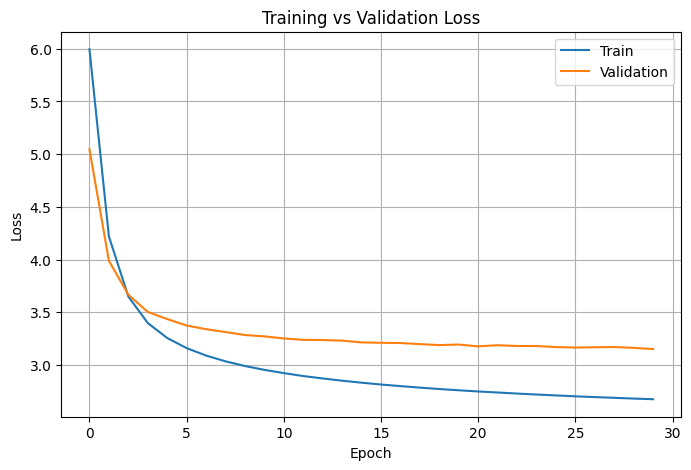

In [85]:
import json
import matplotlib.pyplot as plt

with open(LOG_FILE, "r") as f:
    history = json.load(f)

plt.figure(figsize=(8,5))
plt.plot(history["train_losses"], label="Train")
plt.plot(history["val_losses"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

In [86]:
translate(model, "what is your name?", sp_en, sp_hi, 10, device)

'आपका नाम क्या है?'

In [87]:
translate(model, "hello, which city do you belong to?", sp_en, sp_hi, 10, device)

'नमस्कार, जो शहर आप का है'

In [88]:
translate(model, "what's your father's name?", sp_en, sp_hi, 10, device)

'तुम्हारे पिता का नाम क्या है?'

In [89]:
translate(model, "do you want to eat bruschetta", sp_en, sp_hi, 10, device)

'क्या आप ब्रशेट खाना चाहते हैं'

In [90]:
translate(model, "Hello my name is alibaba, I am from China and my age is 20", sp_en, sp_hi, 30, device)

'नमस्ते मेरा नाम अलीबाबा है, मैं चीन से हूँ और मेरी आयु 20 है'

In [91]:
ckpt = torch.load(f"{CHECKPOINT_DIR}/best.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Best model from epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f}")

Best model from epoch 29, val_loss=3.1517


In [92]:
# Pull raw sentences directly from the underlying dataset -- no padding involved
from torch.utils.data import Subset

val_subset = Subset(val_dataset, range(500))

# Decode a handful of training examples and translate them
check_indices = [10, 50, 100, 200, 350]
for idx in check_indices:
  src_ids, tgt_ids = val_subset[idx]  # raw token ID lists, no padding

  # Decode back to text so you can see what the sentence actually is
  src_text = sp_en.decode(src_ids[:-1])  # strip the EOS_ID we added during tokenization
  tgt_text = sp_hi.decode(tgt_ids)       # ground truth Hindi

  # Translate
  src_tensor = torch.tensor([src_ids], device=device)
  predicted_ids = greedy_decode(model, src_tensor, MAX_SEQ_LEN, device)
  predicted_text = sp_hi.decode(predicted_ids)

  print(f"EN:        {src_text}")
  print(f"HI target: {tgt_text}")
  print(f"HI pred:   {predicted_text}")
  print()

EN:        A very sad incident occurred in Maloya village, which is located on the outskirts of the city, where a newly married woman committed suicide by hanging herself from the fan.
HI target: शहरी के छोर पर बसे मलोया गांव में शुक्रवार को हुई दुखद घटना में नवविवाहिता कोमल ने पंखे से फंदा लगाकर जान दे दी।
HI pred:   मालोया गांव में एक बहुत ही दुख की घटना हुई जो शहर के बाहरी भाग में स्थित है, जहां एक नई विवाहित महिला ने पंखे से अपने को लटकाकर आत्महत्या की।

EN:        The minimum noise level was found to be 72.5 decibels and the maximum 83.6 decibels.
HI target: जांच न्यूनतम ध्वनि प्रदूषण 72.5 और अधिकतम 83.6 पाया गया।
HI pred:   न्यूनतम शोर स्तर 72.5 डेसिबल और अधिकतम 83.6 डेसिबल पाया गया.

EN:        While demanding an investigation into this matter, he has requested that the expenditure of 13th finance commission fund is halted.
HI target: उन्होंने इस मामले की जाच करते हुए 13वें वित आयोग की राशि पर तत्काल रोक लगाने की मांग की है।
HI pred:   इस मामले में जांच की मांग करते समय उन्होंने

In [93]:
translate(model, "My name is Pratyush, I am from Bangalore and I love coding!", sp_en, sp_hi, 30, device)

'मेरा नाम है प्रात्यश, मैं बंगलौर से हूं और मुझे कोडिंग पसंद है!'

In [94]:
!pip install sacrebleu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.4 MB/s eta 0:00:00


In [95]:
# pip install sacrebleu -q
import sacrebleu

def compute_bleu(model, en_lines, hi_lines, sp_en, sp_hi, max_len, device, n=500):
    model.eval()
    hypotheses, references = [], []
    for en, hi in zip(en_lines[:n], hi_lines[:n]):
        pred = translate_beam(model, en, sp_en, sp_hi, max_len, device)
        hypotheses.append(pred)
        references.append(hi)
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])
    return round(bleu.score, 2)

# Run on test set with best model loaded
bleu = compute_bleu(model, test_en, test_hi, sp_en, sp_hi, MAX_SEQ_LEN, device)
print(f"BLEU score: {bleu}")

BLEU score: 18.12


In [96]:
translate(model, "give me a test dataset on which i can test out this transformer model!", sp_en, sp_hi, 40, device)

'मुझे एक टेस्ट dataset पर जिस पर मैं इस ट्रांसफॉर्मर मॉडल का परीक्षण कर सकते हैं दे!'

In [97]:
translate(model, "India is one of the fastest growing economies in the world. Every year, thousands of students graduate from universities and begin their careers in technology, healthcare, education, and business. Many young people are also interested in artificial intelligence and machine learning because these fields offer exciting opportunities.", sp_en, sp_hi, 200, device)

'भारत विश्व की सबसे तेजी से बढ़ती अर्थव्यवस्थाओं में से एक है। प्रत्येक वर्ष विश्वविद्यालयों से हजारों छात्र स्नातक और प्रौद्योगिकी, स्वास्थ्य सेवा, शिक्षा और व्यवसाय में अपने कैरियर आरंभ करते हैं।'

In [98]:
translate(model, "Researchers developed a machine learning model that can detect early signs of heart disease using electrocardiogram data. The model was trained on thousands of patient records and achieved high accuracy during clinical evaluation.", sp_en, sp_hi, 200, device)

'शोधकर्ताओं ने मशीन अधिगम मॉडल विकसित किया जो इलेक्ट्रोकार्डियोग्राम डेटा का उपयोग करके हृदय रोग के प्रारंभिक संकेत का पता लगा सकता है। मॉडल को हजारों रोगी रिकॉर्ड पर प्रशिक्षित किया गया और नैदानिक मूल्यांकन के दौरान उच्च सटीकता प्राप्त की गई।'